In [24]:
%load_ext autoreload
%autoreload 2

import featuregraph as fg

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [25]:
smooth_window = 125

df = fg.datasets.bidmc(subject=1)

df['respiration_smooth'] = df['respiration'].rolling(smooth_window).max().rolling(smooth_window).mean().shift(-smooth_window)
df['respiration_rising'] = df['respiration_smooth'].diff() > 0
df['respiration_falling'] = df['respiration_smooth'].diff() < 0
df['respiration_inactive'] = df['respiration_smooth'].diff() == 0

df['enter_respiration_rising'] = df['respiration_rising'].astype(int).diff() == 1
df['exit_respiration_rising'] = df['respiration_rising'].astype(int).diff() == -1
df['exit_respiration_rising_id'] = df['exit_respiration_rising'].cumsum()
df['index'] = df.index

In [26]:
summarydf = df.groupby('exit_respiration_rising_id').agg(
    respiration_rising_samples=('respiration_rising', 'sum'),
    respiration_falling_samples=('respiration_falling', 'sum'),
    respiration_inactive_samples=('respiration_inactive', 'sum'),
    enter_rising_count=('enter_respiration_rising', 'sum'),
    exit_rising_count=('exit_respiration_rising', 'sum'),
    start_index=('time', 'first'),
    end_index=('time', 'last'),
)

In [27]:
summarydf

,respiration_rising_samples,respiration_falling_samples,respiration_inactive_samples,enter_rising_count,exit_rising_count,start_index,end_index
exit_respiration_rising_id,,,,,,,
0,33,0,0,1,0,0.000,1.248
1,119,119,52,1,1,1.256,3.568
2,105,105,62,1,1,3.576,5.744
3,128,126,40,1,1,5.752,8.096
4,109,109,64,1,1,8.104,10.352
...,...,...,...,...,...,...,...
166,184,182,26,1,1,466.540,469.660
167,168,142,34,1,1,469.670,472.420
168,155,163,32,1,1,472.420,475.220


(<Figure size 1600x1760 with 8 Axes>,
 array([<Axes: ylabel='respiration'>, <Axes: ylabel='respiration_smooth'>,
        <Axes: ylabel='respiration_rising'>,
        <Axes: ylabel='respiration_falling'>,
        <Axes: ylabel='respiration_inactive'>,
        <Axes: ylabel='enter_respiration_rising'>,
        <Axes: ylabel='exit_respiration_rising'>,
        <Axes: xlabel='Time', ylabel='exit_respiration_rising_id'>],
       dtype=object))

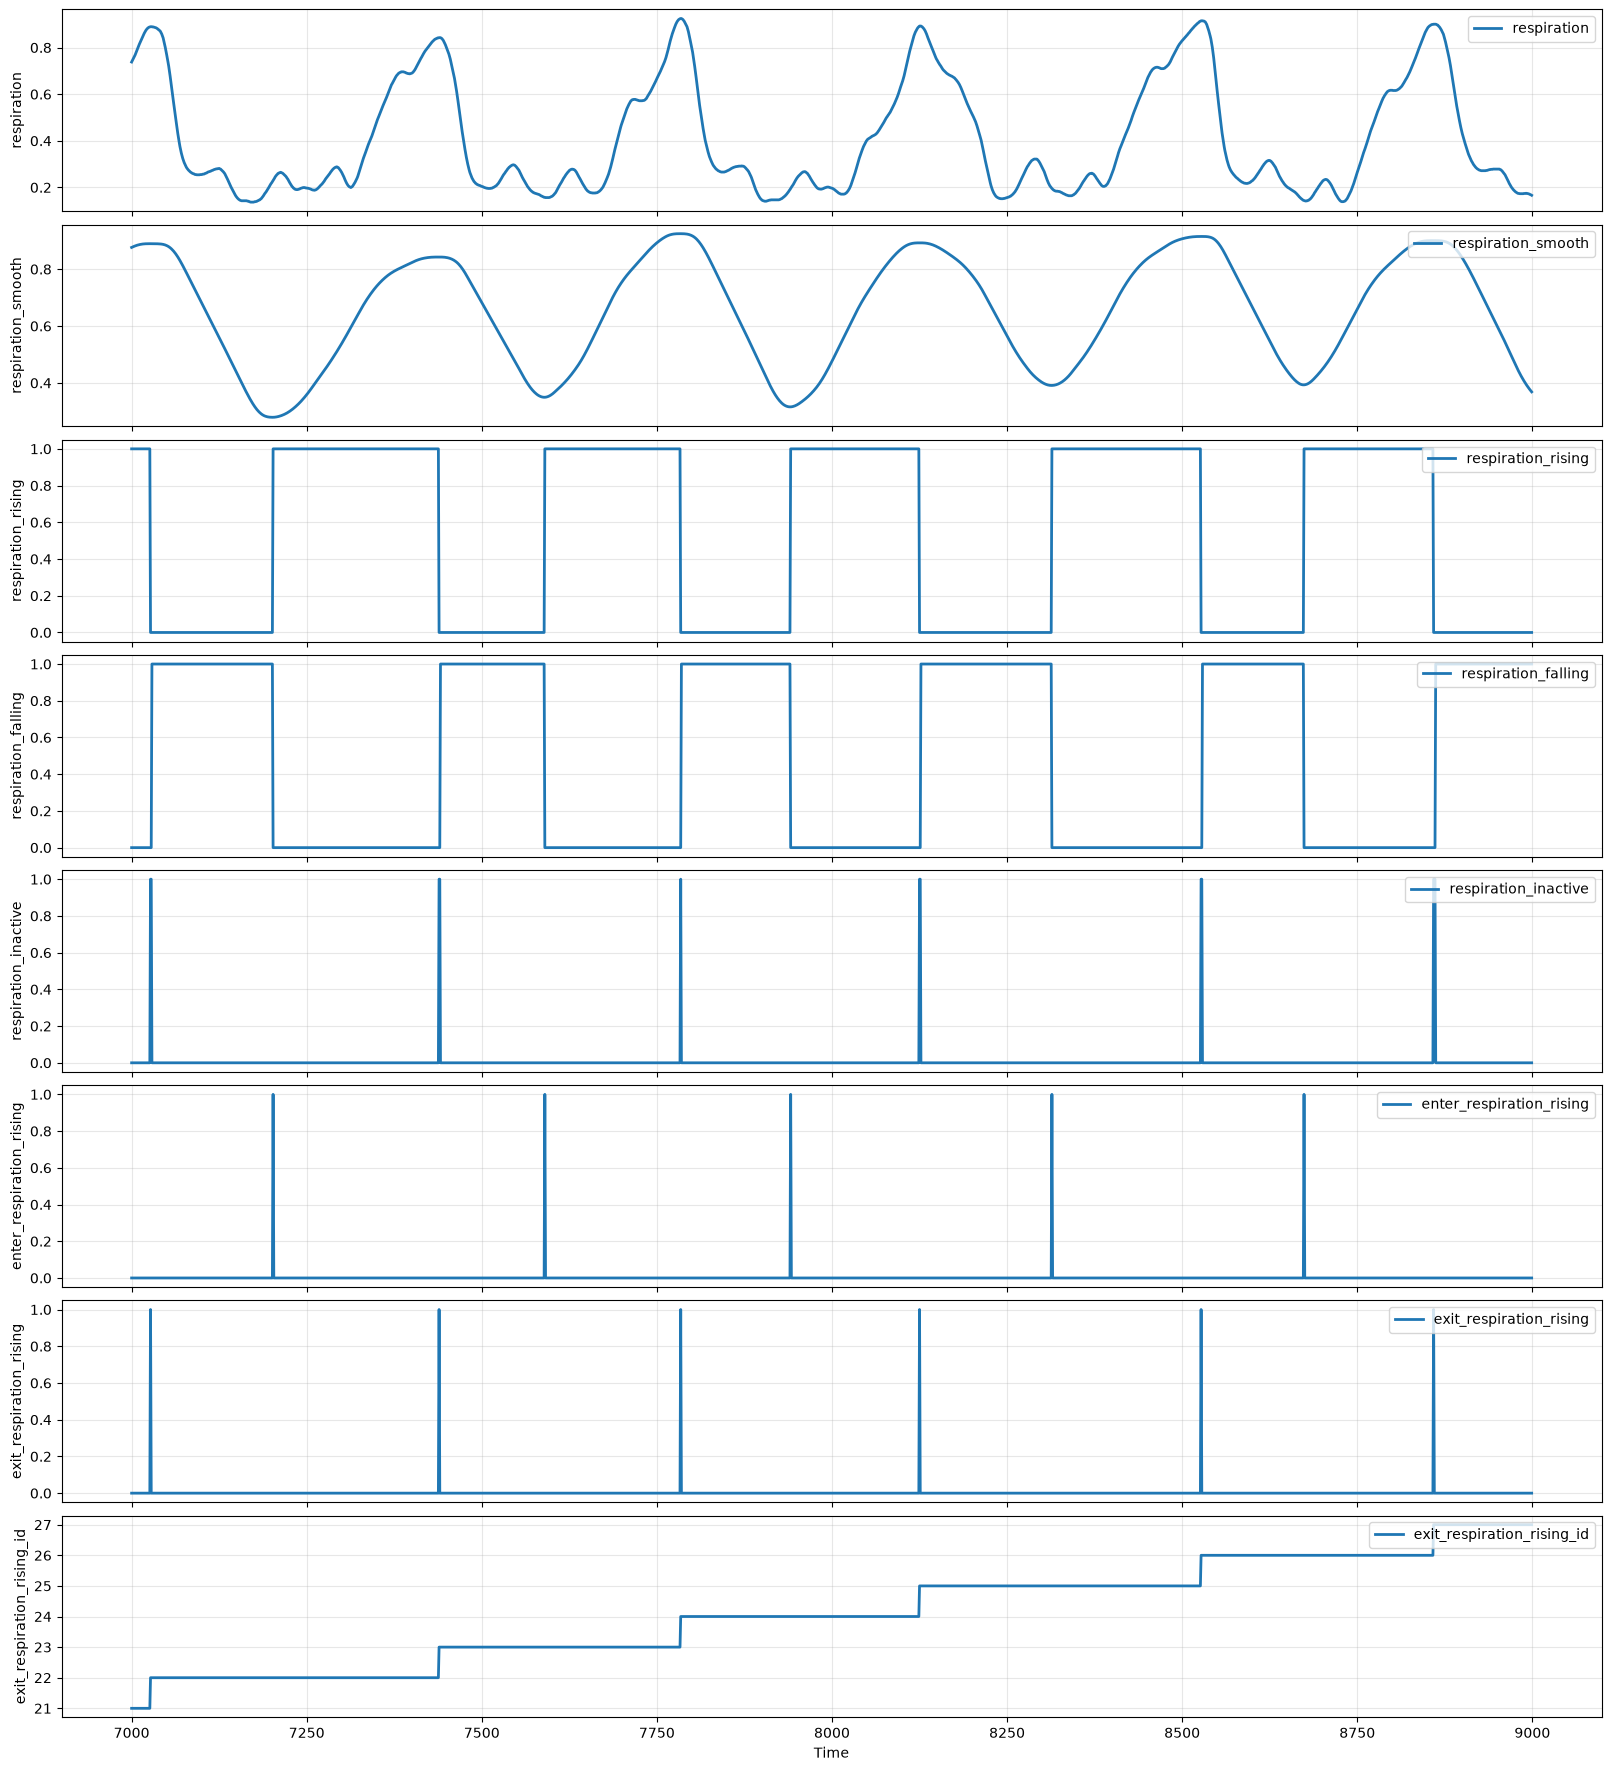

In [28]:
fg.plot(df[7000:9000], [['respiration'],
                              ['respiration_smooth'],
                              ['respiration_rising'],
                              ['respiration_falling'],
                              ['respiration_inactive'],
                              ['enter_respiration_rising'],
                              ['exit_respiration_rising'],
                              ['exit_respiration_rising_id']
                             ]
)